In [1]:
from singleCAM_IROS._pipeline_support import _handle_dirpaths
from typing import Callable

from pathlib import Path

from numpy.typing import NDArray
import numpy as np
from astropy.io.fits.fitsrec import FITS_rec

from bloodmoon.io import simulation_files
from bloodmoon.mask import CodedMaskCamera, codedmask, count
from bloodmoon.images import argmax

import darksun as ds

ds.show.set_figures_darkbkg()

In [2]:
MASK_FITS: str = "wfm_mask_NTHT_20250725.fits"

SKYFIELD: str = "IROSDummy"
DATA_FITS: str = "iros_benchmark_2-50keV_mask_050_1040x17_infdet_1ks"

ID_CAMERA_A: str = "cam1a"
ID_CAMERA_B: str = "cam1b"

UPS_X: int = 10
UPS_Y: int = 5

In [3]:
# load filepaths
mask_path, simul_data, save_path = _handle_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS,
)
wfm: CodedMaskCamera = codedmask(mask_path, UPS_X, UPS_Y)
filepaths: dict[str, dict[str, Path]] = simulation_files(simul_data)


# data from camera A
catalogueA = ds.get_catalogue(filepaths[ID_CAMERA_A]['sources'])
sdlA_detct = ds.get_data(filepaths[ID_CAMERA_A]['detected'])
sdlA_recnstr = ds.get_data(filepaths[ID_CAMERA_A]['reconstructed'])

## data from camera B
#catalogueB = ds.get_catalogue(filepaths[ID_CAMERA_B]['sources'])
#sdlB_detct = ds.get_data(filepaths[ID_CAMERA_B]['detected'])
#sdlB_recnstr = ds.get_data(filepaths[ID_CAMERA_B]['reconstructed'])

In [4]:
from bloodmoon.types import CoordEquatorial
from darksun.benchmarking import source_catalogue_data
from darksun.data import DataLoader, CatalogueLoader

type EnergyRange = tuple[float, float]


def get_source_coords(
    sourceID: str,
    catalogue: CatalogueLoader,
) -> CoordEquatorial:
    """Extracts the source RA/Dec coords from catalogue."""
    data = source_catalogue_data(sourceID, catalogue.DLdata)
    return CoordEquatorial(data['RA'], data['DEC'])

def filter_energy(
    photons: FITS_rec,
    E_min: float | None,
    E_max: float | None,
) -> FITS_rec:
    """Filters the input photons by energy, in [keV]."""
    return ds.filter_data(photons, E_min=E_min, E_max=E_max, coords=None)

## Modelled Source Shadowgram Approach

- Let's fit the detector spatial resolution kernel parameters by applying the instr. effect to the source shadowgram model

- Here the goal is to obtain the kernel parameters by convolving the source model (only vignetted) with the PSFY kernel and minimising the MSE between convolved model and reconstructed detector images

- **NOTE**: I also tried to fit the kernel parameters by analysing the arrays in the sky domain, but the fit did not work (the parameters were badly fitted/not fitted at all)

In [5]:
from dataclasses import dataclass
from functools import partial

from scipy.ndimage import gaussian_filter
from scipy.optimize import curve_fit
from scipy.signal import convolve

from bloodmoon.images import fshift
from bloodmoon.mask import decode
from bloodmoon.optim import _detector_footprint_cached, apply_vignetting


@dataclass
class OptParams:
    """Optimisation results."""
    params: NDArray
    covar: NDArray

def project_mask_pattern(
    camera: CodedMaskCamera,
    shift_x: float,
    shift_y: float,
) -> NDArray:
    """Projects the camera mask pattern on the detector plane."""
    pxdimy, pxdimx = (
        camera.specs.mask_deltay / camera.upscale_f.y,
        camera.specs.mask_deltax / camera.upscale_f.x,
    )
    fr, fc = (
        (-1.0) * shift_y / pxdimy,
        (-1.0) * shift_x / pxdimx,
    )
    mask_shifted = fshift(camera.mask.astype(float), fr, fc)
    mask_vignetted = apply_vignetting(camera, mask_shifted, shift_x, shift_y)
    return mask_vignetted

def extract_detector(
    camera: CodedMaskCamera,
    mask_projection: NDArray,
) -> NDArray:
    """
    Extracts the detector image from the mask pattern projection on the detector plane.
    """
    i_min, i_max, j_min, j_max = _detector_footprint_cached(camera)
    detector = mask_projection[i_min:i_max, j_min:j_max]
    detector *= camera.bulk
    detector /= np.sum(detector)
    return detector

#def process_skyimg(
#    camera: CodedMaskCamera,
#    sky: NDArray,
#    pos: tuple[int, int],
#    offset: tuple[int, int],
#) -> NDArray:
#    """
#    Processes the sky image for optimisation.
#    """
#    _slit_x, _slit_y = ds.psf_extension(camera)
#    crop_y, crop_x = _slit_y + offset[0], _slit_x + offset[1]
#    i, j = pos
#    slice_y, slice_x = (
#        slice(i - crop_y, i + crop_y + 1),
#        slice(j - crop_x, j + crop_x + 1),
#    )
#    cropped = sky[slice_y, slice_x]
#    return cropped.flatten()



def compute_psfy_kernel(
    x: NDArray,
    alpha: float,
    beta: float,
    sigma: float,
) -> NDArray:
    """Computes the LEM-X detector spatial resolution kernel from input params."""
    modsec = 1.0 / np.cosh(np.abs(x / alpha) ** beta)
    kernel = modsec.reshape(len(x), -1)
    # from tests, the modsech should be modulated with a Gaussian
    psfy = gaussian_filter(kernel, sigma, mode='constant', cval=0.0)
    return psfy / np.sum(psfy)

def apply_detector_resolution(
    shadowgram: NDArray,
    kernel: NDArray,
) -> NDArray:
    """
    Applies finite detector spatial resolution effects to a shadowgram.
    """
    return convolve(shadowgram, kernel, mode="same")


def config_KernelFitFunc(
    camera: CodedMaskCamera,
    shift_x: float,
    shift_y: float,
    cts: float,
    #arg_sky: tuple[int, int],
    #offset: tuple[int, int],
) -> Callable[[NDArray, float, float, float], NDArray]:
    """
    Initialises the kernel model.
    """
    # we take a whole slit to have a good kernel spatial extension
    px_ydim = camera.specs.mask_deltay / camera.upscale_f.y
    slit_dim = camera.specs.slit_deltay
    # the kernel must have the same binning as the mask elements
    bins = np.linspace(-slit_dim, slit_dim, int(2 * slit_dim / px_ydim) + 1)
    make_kernel: Callable = partial(compute_psfy_kernel, bins)
    # compute projected source shadowgram (non normalised)
    sg = project_mask_pattern(camera, shift_x, shift_y)

    def f(x: NDArray, alpha: float, beta: float, sigma: float) -> NDArray:
        """Models the PSFY kernel and performs the convolution with detected array."""
        kernel = make_kernel(alpha, beta, sigma)
        conv = apply_detector_resolution(sg, kernel)
        detector = extract_detector(camera, conv) * cts
        #sky = decode(camera, detector)
        #return process_skyimg(camera, sky, arg_sky, offset)
        return detector.flatten()
    
    return f

In [6]:
def kernel_params_fit(
    camera: CodedMaskCamera,
    shift_x: float,
    shift_y: float,
    cts: float,
    reconstructed: NDArray,
    #arg_sky: tuple[int, int],
    #offset: tuple[int, int],
    verbose: bool = True,
) -> OptParams:
    """Performs the fit of the detector spatial resolution kernel params."""
    #func = config_KernelFitFunc(
    #    camera, shift_x, shift_y, sky[arg_sky], arg_sky, offset,
    #)
    func = config_KernelFitFunc(camera, shift_x, shift_y, cts)

    # - setup ydata
    #ydata = process_skyimg(camera, sky, arg_sky, offset)
    ydata = reconstructed.flatten()
    # - setup p0 from current kernel (alpha, beta, sigma)
    start_params_vals = np.array([0.54597, 0.73634, 0.17750])
    # - setup boundaries
    bounds = [
        (0.0, 0.0, 0.0),
        (1.0, 1.0, 10.0),
    ]
    # - setup least squares kwargs
    lsq_kwargs = {
        'jac': '3-point',
        'ftol': 1e-8,
        'xtol': 1e-8,
        'x_scale': 'jac',
        'loss': 'linear',
    }

    # perform optimisation
    popt, pcov, info, msg, iflag = curve_fit(
        f=func,
        xdata=np.arange(len(ydata)),
        ydata=ydata,
        p0=start_params_vals,
        bounds=bounds,
        method='trf',
        full_output=True,
        **lsq_kwargs,
    )
    if verbose:
        def comp_gain(start: float, comp: float) -> float:
            """Computes fitted parameter value wrt start in perc."""
            return float(np.sign(start) * (comp - start) * 100 / start)
        
        a_start, b_start, s_start = map(float, start_params_vals)
        a, b, s = map(float, popt)
        da, db, dsigma = map(float, np.sqrt(np.diag(pcov)))
        print(
            f'\n'
            f'## Optimisation Results:\n'
            f'  - alpha, beta, sigma START: {a_start, b_start, s_start}\n'

            f'  - alpha OPTIM.: {a} +/- {da}\n'
            f'  - beta OPTIM.: {b} +/- {db}\n'
            f'  - sigma OPTIM.: {s} +/- {dsigma}\n'

            f'  - alpha GAIN: {comp_gain(a_start, a):.3f}%\n'
            f'  - beta GAIN: {comp_gain(b_start, b):.3f}%\n'
            f'  - sigma GAIN: {comp_gain(s_start, s):.3f}%'
        )
        routine_status = [
            'Convergence in chi-square values',
            'Convergence in parameter values',
            'Convergence in both chi-square and parameter values',
            'Convergence in orthogonality',
        ]
        print(
            f'## Fit Report:\n'
            f'  - func calls (also # of iters): {info['nfev']}\n'
            f'  - procedure msg (`ftol`, `xtol` = {lsq_kwargs['ftol']}, {lsq_kwargs['xtol']}): {msg}\n'
            f'  - success status {iflag}: {routine_status[iflag - 1]}\n'
        )

    return OptParams(popt, pcov)

In [7]:
from bloodmoon.coords import equatorial2shift

def extract_localcoords(
    sourceID: str,
    camera: CodedMaskCamera,
    sdl: DataLoader,
    catalogue: CatalogueLoader,
) -> tuple[float, float]:
    """Extracts input source coords in camera local-frame system."""
    coords: CoordEquatorial = get_source_coords(sourceID, catalogue)
    localcrds = equatorial2shift(sdl, camera, coords.ra, coords.dec)
    return localcrds

def get_source_phs_list(
    sourceID: str,
    eband: EnergyRange,
    sdl: DataLoader,
    catalogue: CatalogueLoader,
) -> FITS_rec:
    """Extracts source observed photons list in given energy range."""
    coords: CoordEquatorial = get_source_coords(sourceID, catalogue)
    phs: FITS_rec = ds.select_source_photons(coords, sdl.DLdata, False)
    eband_phs: FITS_rec = filter_energy(phs, *eband)
    return eband_phs


sourceID: str = 's17'
eband: EnergyRange = (7.0, 8.0)  # [keV]

shift_x, shift_y = extract_localcoords(sourceID, wfm, sdlA_recnstr, catalogueA)
eband_phs: FITS_rec = get_source_phs_list(sourceID, eband, sdlA_recnstr, catalogueA)

In [8]:
reconstructed: NDArray = count(wfm, eband_phs)[0]
sky_reconstructed = decode(wfm, reconstructed)

cts: float = sky_reconstructed.max() + 1.5e3

#arg_sky: tuple[int, int] = argmax(sky_reconstructed)
#offset: tuple[int, int] = (
#    5 * wfm.upscale_f.y,
#    10 * wfm.upscale_f.x,
#)

# NOTE:
#   - (2.0, 3.0) keV: gain = 1.12086
#   - (4.0, 5.0) keV: gain = 1.06679

print(
    f'Cts gain wrt sky max: {1 + (cts - sky_reconstructed.max()) / sky_reconstructed.max():.6f} %'
)

## USING BULK MASK with 1.5 mm cover ##
Cts gain wrt sky max: 1.036644 %


In [9]:
params: OptParams = kernel_params_fit(wfm, shift_x, shift_y, cts, reconstructed)
#params: OptParams = kernel_params_fit(wfm, shift_x, shift_y, sky_reconstructed, arg_sky, offset)


## Optimisation Results:
  - alpha, beta, sigma START: (0.54597, 0.73634, 0.1775)
  - alpha OPTIM.: 0.5403790091940254 +/- 0.04475852422882675
  - beta OPTIM.: 0.9975190094191335 +/- 0.06499961620286913
  - sigma OPTIM.: 0.0035194518881591086 +/- 0.0
  - alpha GAIN: -1.024%
  - beta GAIN: 35.470%
  - sigma GAIN: -98.017%
## Fit Report:
  - func calls (also # of iters): 12
  - procedure msg (`ftol`, `xtol` = 1e-08, 1e-08): `ftol` termination condition is satisfied.
  - success status 2: Convergence in parameter values



In [10]:
def gen_sg_model(
    camera: CodedMaskCamera,
    shift_x: float,
    shift_y: float,
    psfy_params: NDArray,
) -> NDArray:
    """Computes the source shadowgram model given the PSFY kernel params."""
    # compute PSFY kernel
    px_ydim = camera.specs.mask_deltay / camera.upscale_f.y
    slit_dim = camera.specs.slit_deltay
    bins = np.linspace(-slit_dim, slit_dim, int(2 * slit_dim / px_ydim) + 1)
    kernel: NDArray = compute_psfy_kernel(bins, *psfy_params)
    # compute shadowgram
    sg = project_mask_pattern(camera, shift_x, shift_y)
    conv = apply_detector_resolution(sg, kernel)
    detector = extract_detector(camera, conv)
    return detector

def gen_sky_model(
    camera: CodedMaskCamera,
    shift_x: float,
    shift_y: float,
    cts: float,
    psfy_params: NDArray,
) -> NDArray:
    """Computes the source sky model given the PSFY kernel params."""
    detector = gen_sg_model(camera, shift_x, shift_y, psfy_params)
    sky = decode(camera, cts * detector)
    return sky


skymodel: NDArray = gen_sky_model(wfm, shift_x, shift_y, cts, params.params)

In [11]:
from bloodmoon.optim import model_sky

bm_model = model_sky(wfm, shift_x, shift_y, cts)

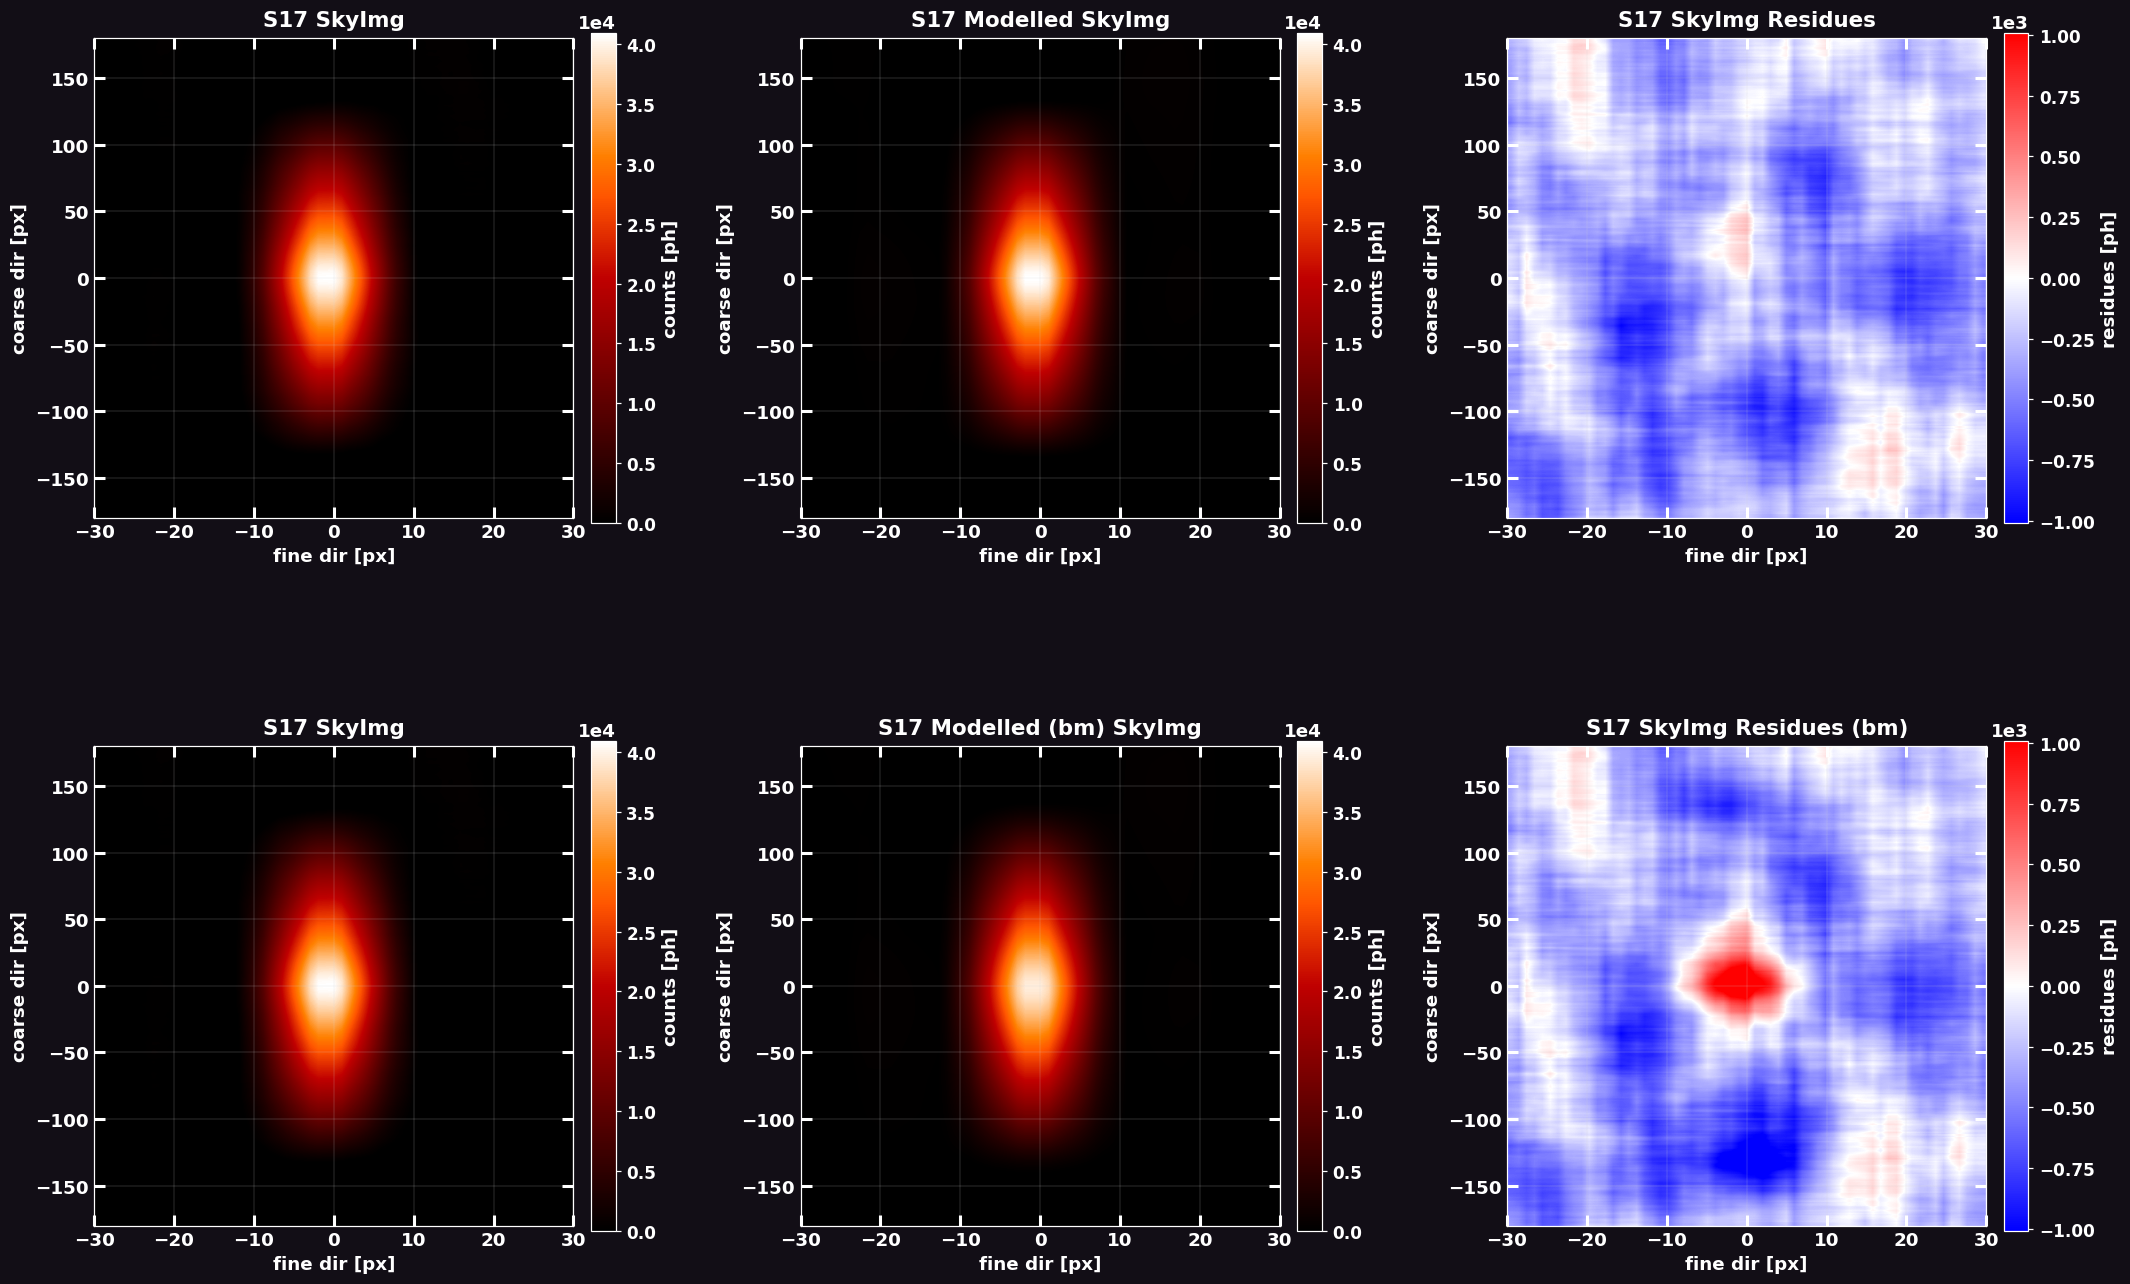

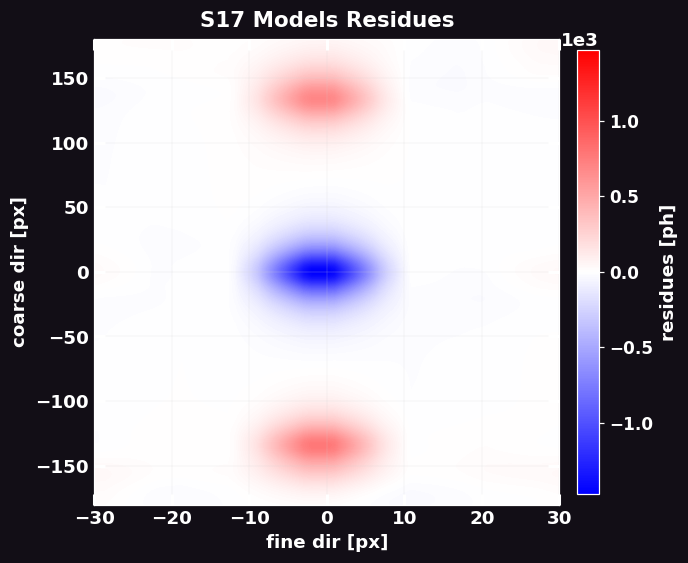

In [12]:
### Sky Images Plots:
#   - Reconstructed Phs from WM
#   - Modelled with current Fit
#   - Modelled from BM (with current fixed params)

pos = argmax(sky_reconstructed)
offset = (
    5 * wfm.upscale_f.y,
    2 * wfm.upscale_f.x,
)
_fine, _coarse = ds.psf_extension(wfm)
crp = (
    _coarse + offset[0], _fine + offset[1],
)


skycrp, modelcrp, bm_modelcrp = map(
    lambda x: ds.crop(x, pos, crp), (sky_reconstructed, skymodel, bm_model),
)

_labels: dict = {
    'xlabel': 'fine dir [px]',
    'ylabel': 'coarse dir [px]',
    'cbarlabel': 'counts [ph]',
}
_imgkwargs: dict = {
    'aspect': crp[1] / crp[0],
    'extent': [-crp[1], crp[1], -crp[0], crp[0]],
    'vmin': 0.0,
    'vmax': skycrp.max(),
    'cmap': 'gist_heat',
    'interpolation': 'bilinear',
}
res = skycrp - modelcrp
vlim = np.max(np.abs(res))

sky_dmaps = (
    ds.map4image(
        img=skycrp,
        title=f'{sourceID.upper()} SkyImg',
        img_kwargs=_imgkwargs,
        **_labels,
    ),
    ds.map4image(
        img=modelcrp,
        title=f'{sourceID.upper()} Modelled SkyImg',
        img_kwargs=_imgkwargs,
        **_labels,
    ),
    ds.map4image(
        img=res,
        title=f'{sourceID.upper()} SkyImg Residues',
        xlabel=_labels['xlabel'],
        ylabel=_labels['ylabel'],
        cbarlabel='residues [ph]',
        img_kwargs={
            **_imgkwargs,
            'vmin': -vlim,
            'vmax': vlim,
            'cmap': 'bwr',
        },
    ),
)

bm_res = skycrp - bm_modelcrp
bm_dmaps = (
    ds.map4image(
        img=skycrp,
        title=f'{sourceID.upper()} SkyImg',
        img_kwargs=_imgkwargs,
        **_labels,
    ),
    ds.map4image(
        img=bm_modelcrp,
        title=f'{sourceID.upper()} Modelled (bm) SkyImg',
        img_kwargs=_imgkwargs,
        **_labels,
    ),
    ds.map4image(
        img=bm_res,
        title=f'{sourceID.upper()} SkyImg Residues (bm)',
        xlabel=_labels['xlabel'],
        ylabel=_labels['ylabel'],
        cbarlabel='residues [ph]',
        img_kwargs={
            **_imgkwargs,
            'vmin': -vlim,
            'vmax': vlim,
            'cmap': 'bwr',
        },
    ),
)

ds.image_plot(
    dmaps=(*sky_dmaps, *bm_dmaps),
    ncols=3,
    nrows=2,
)

models_res = res - bm_res
vlim = np.max(np.abs(models_res))
ds.image_plot(
    ds.map4image(
        img=models_res,
        title=f'{sourceID.upper()} Models Residues',
        xlabel=_labels['xlabel'],
        ylabel=_labels['ylabel'],
        cbarlabel='residues [ph]',
        img_kwargs={
            **_imgkwargs,
            'vmin': -vlim,
            'vmax': vlim,
            'cmap': 'bwr',
        },
    ),
)

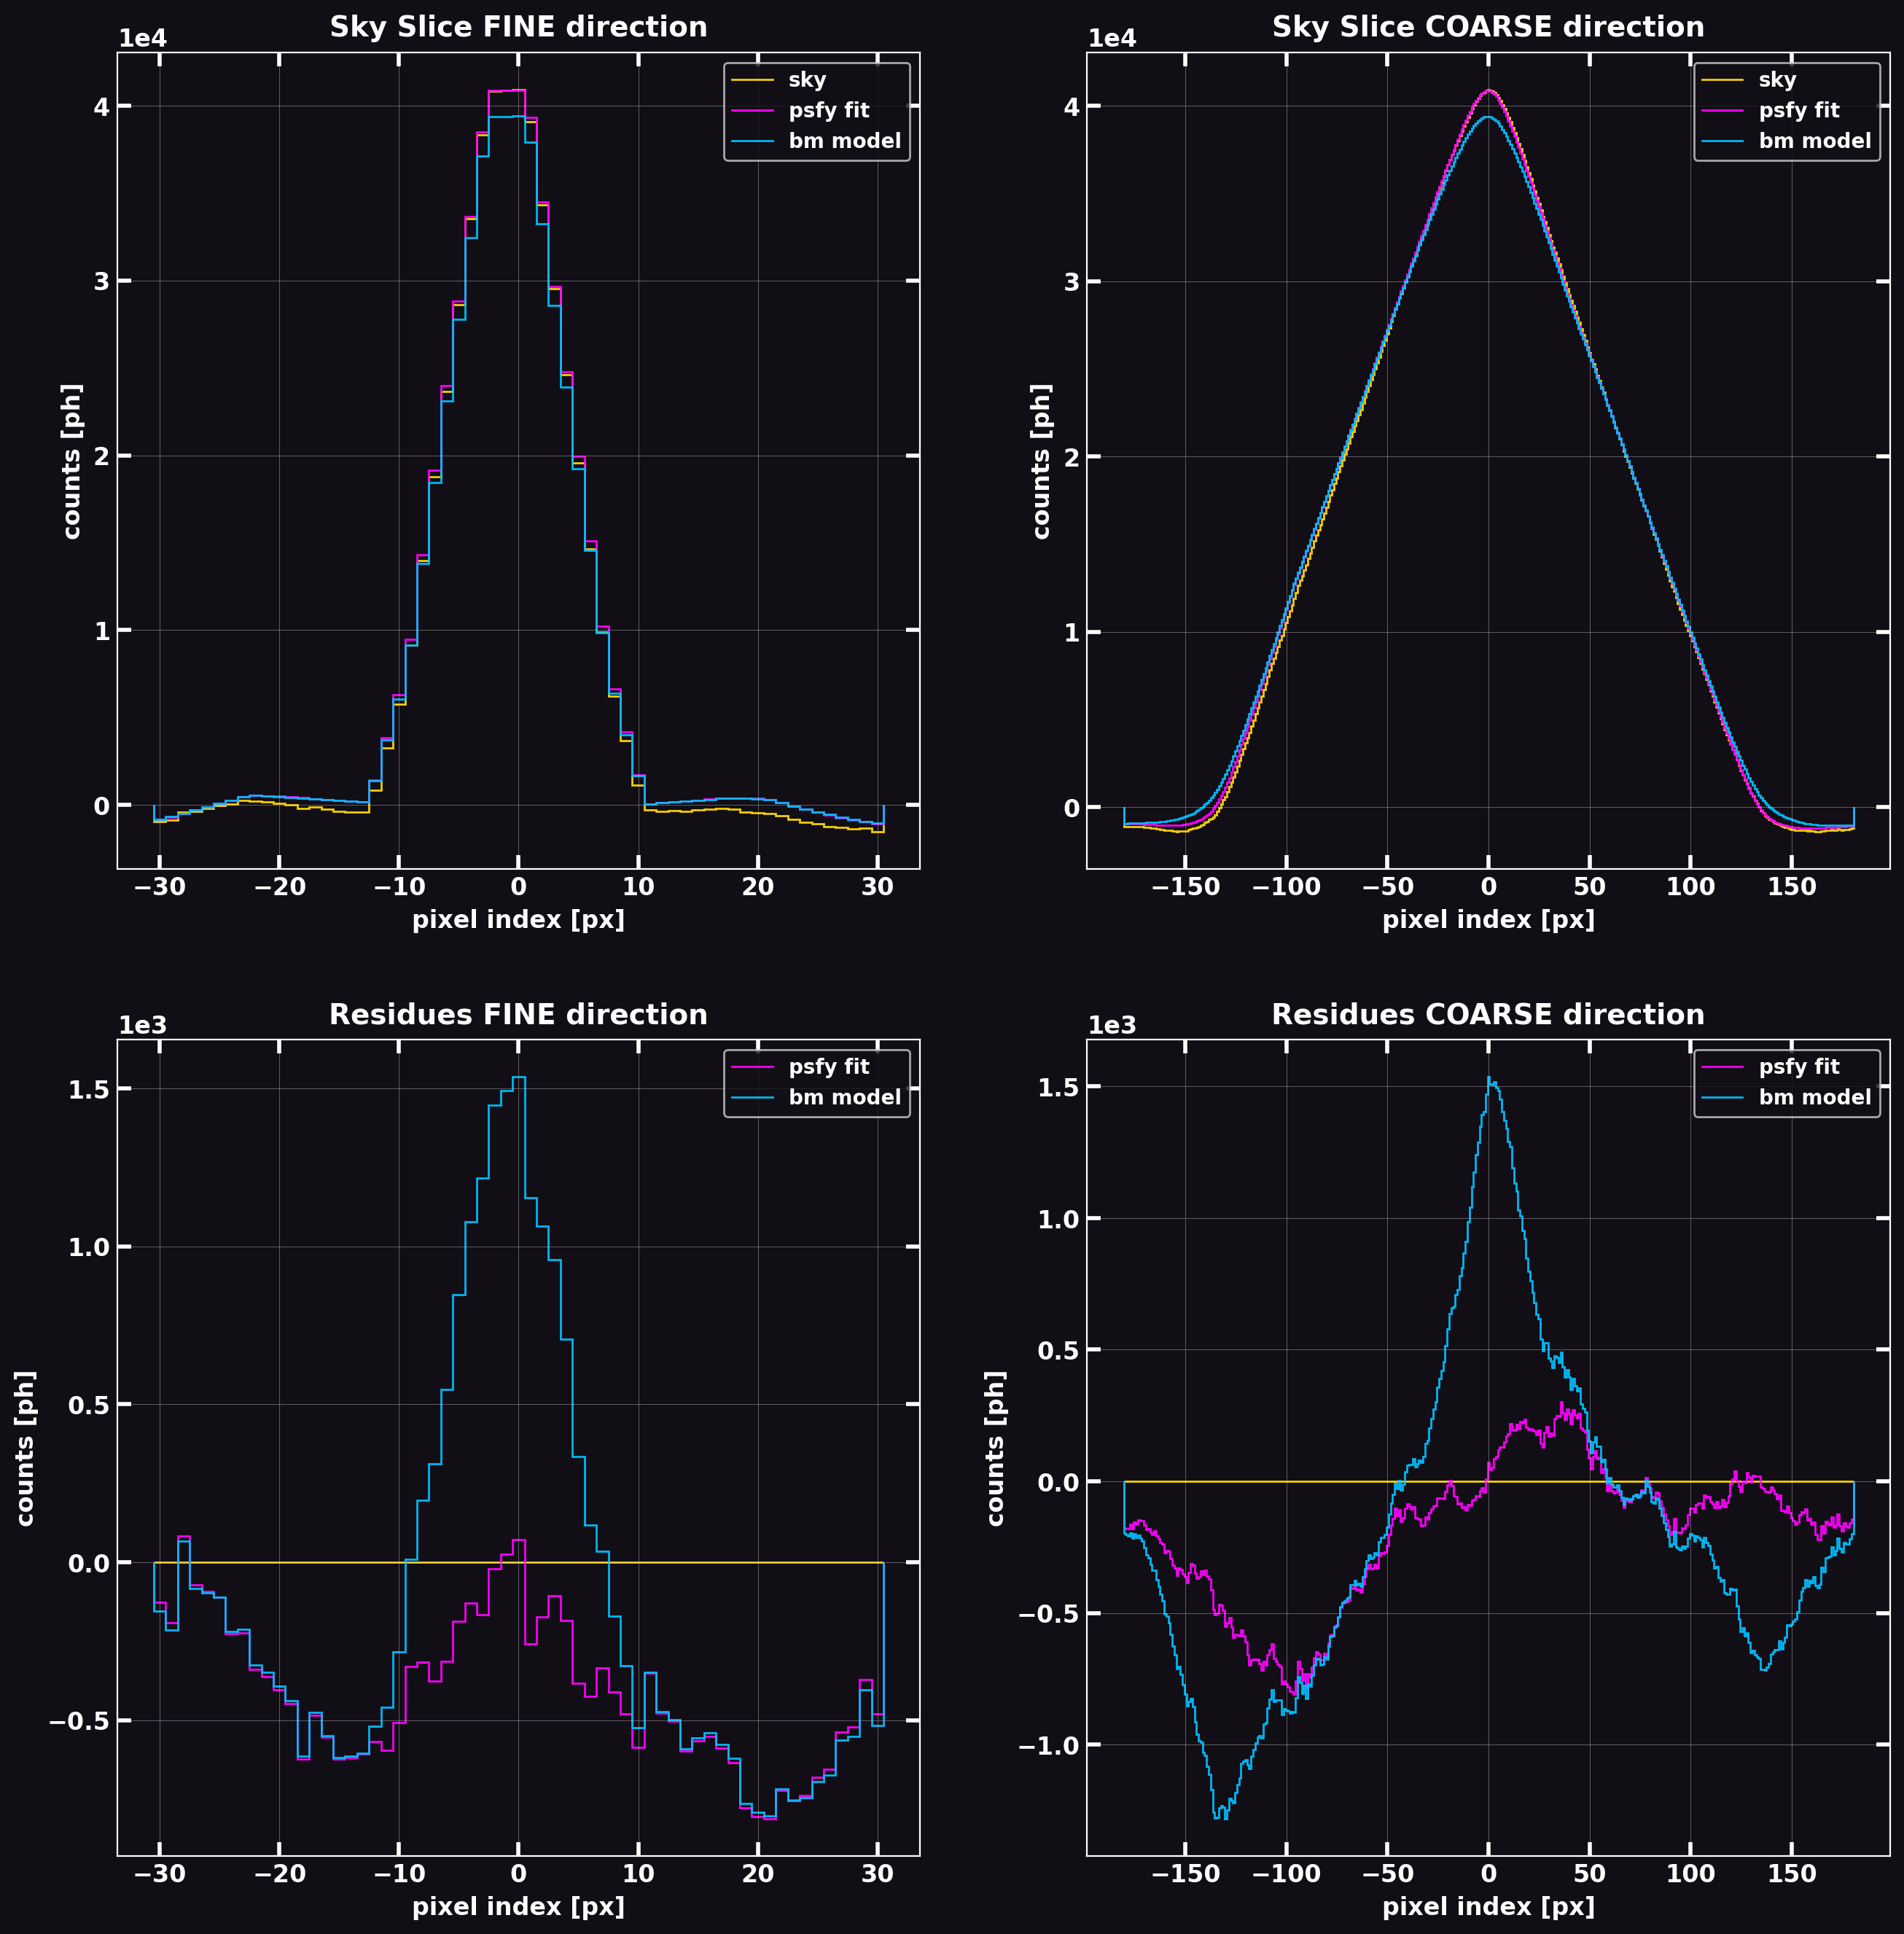

In [13]:
### Profiles Plots

def extract_profile(arr: NDArray, pos: tuple[int, int] | None = None) -> NDArray:
    """Extracts the profile of the input array at given pos."""
    if pos is not None:
        i, j = pos
    else:
        i, j = tuple((s - 1) // 2 for s in arr.shape)
    return arr[i, :], arr[:, j]


arrs = (skycrp, modelcrp, bm_modelcrp)
clps_x, clps_y = zip(
    *tuple(extract_profile(arr) for arr in arrs)
)

res_arrs = (np.zeros_like(res), res, bm_res)
res_clps_x, res_clps_y = zip(
    *tuple(extract_profile(arr) for arr in res_arrs)
)

_get_phase: Callable[[NDArray], NDArray] = lambda x: np.arange(len(x) + 1) - len(x) // 2 - 0.5
_labels: dict = {
    'xlabel': 'pixel index [px]',
    'ylabel': 'counts [ph]',
    'labels': ('sky', 'psfy fit', 'bm model'),
    'color': ('Gold', 'Fuchsia', 'DeepSkyBlue'),
    'style': 'stairs',
}
dmap_clps_x = ds.map4plot(
    arrs=clps_x,
    title='Sky Slice FINE direction',
    x=_get_phase(clps_x[0]),
    **_labels,
)
dmap_clps_y = ds.map4plot(
    arrs=clps_y,
    title='Sky Slice COARSE direction',
    x=_get_phase(clps_y[0]),
    **_labels,
)

_labels['labels'] = ('', 'psfy fit', 'bm model')
res_dmap_clps_x = ds.map4plot(
    arrs=res_clps_x,
    title='Residues FINE direction',
    x=_get_phase(clps_x[0]),
    **_labels,
)
res_dmap_clps_y = ds.map4plot(
    arrs=res_clps_y,
    title='Residues COARSE direction',
    x=_get_phase(clps_y[0]),
    **_labels,
)
ds.plot(
    dmaps=(
        dmap_clps_x, dmap_clps_y,
        res_dmap_clps_x, res_dmap_clps_y,
    ),
    ncols=2,
    nrows=2,
)

In [14]:
# fit with `cts = sky_reconstructed.max()`  (less cts than reconstructed  ~6e3 cts)
alpha, beta, sigma = (
    0.7865632999868843,
    0.9999998594886309,
    9.999959546106165,
)
# fit with `cts = reconstructed.sum()`  (more cts than reconstructed  ~1e4 cts)
alpha, beta, sigma = (
    0.20636344189495331,
    0.3868789506300094,
    0.055463384701258514,
)
# NOTE:
#   - the discrepancy between sky peak cts and tot phs on detector may be due to the binning:
#     digitalising the counts we have the 50% prob that a px may fall in one
#     or in the adjacent px, thus reducing the counts per px by a factor 1/2
#   - maybe also due to reconstruction efficiency wrt source position in FoV

# fit with `cts = 1.12 * sky_reconstructed.max()`  (res <~ 1e3)  [2.0, 3.0]keV
alpha, beta, sigma = (
    0.9999120378885141,
    0.8528812697694608,
    6.009390047958758,
)
# fit with `cts = 1.07 * sky_reconstructed.max()`  (res <~ 1e3)  [4.0, 5.0]keV
alpha, beta, sigma = (
    0.6356688942407013,
    0.8405322141251858,
    0.24151894455970735,  # +/- 391 hmmmmm
)

In [15]:
### Profiles Plots

from typing import Any

def collapse_view(
    arr: NDArray,
    method: Callable[[NDArray, Any], NDArray] = np.mean,
) -> tuple[NDArray, NDArray]:
    """
    Collapses the elements of a 2D array by applying
    the given method along the (col, row) array axes.
    """
    return method(arr, axis=0), method(arr, axis=1)


if False:
    arrs = (skycrp, modelcrp, bm_modelcrp)
    clps_x, clps_y = zip(
        *tuple(collapse_view(arr) for arr in arrs)
    )

    res_arrs = (np.zeros_like(res), res, bm_res)
    res_clps_x, res_clps_y = zip(
        *tuple(collapse_view(arr) for arr in res_arrs)
    )

    _get_phase: Callable[[NDArray], NDArray] = lambda x: np.arange(len(x) + 1) - len(x) // 2 - 0.5
    _labels: dict = {
        'xlabel': 'pixel index [px]',
        'ylabel': 'counts [ph]',
        'labels': ('sky', 'psfy fit', 'bm model'),
        'color': ('OrangeRed', 'Fuchsia', 'DeepSkyBlue'),
        'style': 'stairs',
    }
    dmap_clps_x = ds.map4plot(
        arrs=clps_x,
        title='Sky Avg FINE direction',
        x=_get_phase(clps_x[0]),
        **_labels,
    )
    dmap_clps_y = ds.map4plot(
        arrs=clps_y,
        title='Sky Avg COARSE direction',
        x=_get_phase(clps_y[0]),
        **_labels,
    )

    _labels['labels'] = ('', 'psfy fit', 'bm model')
    res_dmap_clps_x = ds.map4plot(
        arrs=res_clps_x,
        title='Residues FINE direction',
        x=_get_phase(clps_x[0]),
        **_labels,
    )
    res_dmap_clps_y = ds.map4plot(
        arrs=res_clps_y,
        title='Residues COARSE direction',
        x=_get_phase(clps_y[0]),
        **_labels,
    )
    ds.plot(
        dmaps=(
            dmap_clps_x, dmap_clps_y,
            res_dmap_clps_x, res_dmap_clps_y,
        ),
        ncols=2,
        nrows=2,
    )

<br>

<br>

<br>

## WM Data Approach

- Let's fit the detector spatial resolution kernel parameters by applying the instr. effect to the detected photons

- Here the goal is to obtain the reconstructed list of photons by convolving the detected detector image with the PSFY kernel and minimising the MSE between convolved detected and reconstructed detector images

- **NOTE**: I first tried to fit the kernel parameters by analysing the sky images domain, but the fit did not work (the parameters were badly fitted/not fitted at all)

In [16]:
assert False

AssertionError: 

In [ ]:
from dataclasses import dataclass

from scipy.ndimage import gaussian_filter
from scipy.optimize import curve_fit
from scipy.signal import convolve

@dataclass
class OptParams:
    """Optimisation results."""
    params: NDArray
    covar: NDArray


#def process_skyimg(
#    camera: CodedMaskCamera,
#    sky: NDArray,
#    pos: tuple[int, int],
#    offset: tuple[int, int],
#) -> NDArray:
#    """
#    Processes the sky image for optimisation.
#    """
#    _slit_x, _slit_y = ds.psf_extension(camera)
#    crop_y, crop_x = _slit_y + offset[0], _slit_x + offset[1]
#    i, j = pos
#    slice_y, slice_x = (
#        slice(i - crop_y, i + crop_y + 1),
#        slice(j - crop_x, j + crop_x + 1),
#    )
#    cropped = sky[slice_y, slice_x]
#    return cropped.flatten()


def config_func(
    camera: CodedMaskCamera,
    detected: NDArray,
    #arg_sky: tuple[int, int],
    #offset: tuple[int, int],
) -> Callable[[NDArray, float, float, float], NDArray]:
    """
    Initialises the kernel model.
    """
    # we take a whole slit to have a good kernel spatial extension
    px_ydim = camera.specs.mask_deltay / camera.upscale_f.y
    slit_dim = camera.specs.slit_deltay
    # the kernel must have the same binning as the mask elements
    bins = np.linspace(-slit_dim, slit_dim, int(2 * slit_dim / px_ydim) + 1)
    
    def _wfm_kernel(alpha: float, beta: float, sigma: float) -> NDArray:
        """LEM-X detector spatial resolution kernel."""        
        PSFY_GAUSS_PARAMS = {
            'mode': 'constant',
            'cval': 0.0,
        }
        modsec = 1.0 / np.cosh(np.abs(bins / alpha) ** beta)
        kernel = modsec.reshape(len(bins), -1)
        # from tests, the modsech should be modulated with a Gaussian
        psfy = gaussian_filter(kernel, sigma, **PSFY_GAUSS_PARAMS)
        return psfy / np.sum(psfy)

    def f(x: NDArray, alpha: float, beta: float, sigma: float) -> NDArray:
        """Models the PSFY kernel and performs the convolution with detected array."""
        conv = convolve(detected, _wfm_kernel(alpha, beta, sigma), mode="same")
        #sky = decode(camera, conv)
        #return process_skyimg(camera, sky, arg_sky, offset)
        return conv.flatten()
    
    return f


def kernel_params_fit(
    camera: CodedMaskCamera,
    detected: NDArray,
    reconstructed: NDArray,
    #arg_sky: tuple[int, int],
    #offset: tuple[int, int],
    verbose: bool = True,
) -> OptParams:
    """Performs the fit of the detector spatial resolution kernel params."""
    # setup skies
    #_sky = decode(camera, reconstructed)
    #ydata = process_skyimg(camera, _sky, arg_sky, offset)
    ydata = reconstructed.flatten()
    # setup func
    #func = config_func(camera, detected, arg_sky, offset)
    func = config_func(camera, detected)
    # setup p0 from current kernel (alpha, beta, sigma)
    start_params_vals = np.array([0.54597, 0.73634, 0.17750])
    # setup boundaries
    bounds = [
        (0.0, 0.0, 0.0),
        (1.0, 1.0, 10.0),
    ]
    # setup least squares kwargs
    lsq_kwargs = {
        'jac': '3-point',
        'ftol': 1e-8,
        'xtol': 1e-8,
        'x_scale': 'jac',
        'loss': 'linear',
    }
    # perform optimisation
    popt, pcov, info, msg, iflag = curve_fit(
        f=func,
        xdata=np.arange(len(ydata)),
        ydata=ydata,
        p0=start_params_vals,
        bounds=bounds,
        method='trf',
        full_output=True,
        **lsq_kwargs,
    )
    if verbose:
        a_start, b_start, s_start = map(float, start_params_vals)
        a, b, s = map(float, popt)
        da, db, dsigma = map(float, np.sqrt(np.diag(pcov)))
        print(
            f'\n'
            f'## Optimisation Results:\n'
            f'  - alpha, beta, sigma START: {a_start, b_start, s_start}\n'

            f'  - alpha OPTIM.: {a} +/- {da}\n'
            f'  - beta OPTIM.: {b} +/- {db}\n'
            f'  - sigma OPTIM.: {s} +/- {dsigma}\n'

            f'  - alpha GAIN: {(a - a_start) * 100 / a_start:.3f}%\n'
            f'  - beta GAIN: {(b - b_start) * 100 / b_start:.3f}%\n'
            f'  - sigma GAIN: {(s - s_start) * 100 / s_start:.3f}%'
        )
        routine_status = [
            'Convergence in chi-square values',
            'Convergence in parameter values',
            'Convergence in both chi-square and parameter values',
            'Convergence in orthogonality',
        ]
        print(
            f'## Fit Report:\n'
            f'  - func calls (also # of iters): {info['nfev']}\n'
            f'  - procedure msg (`ftol`, `xtol` = {lsq_kwargs['ftol']}, {lsq_kwargs['xtol']}): {msg}\n'
            f'  - success status {iflag}: {routine_status[iflag - 1]}\n'
        )

    return OptParams(popt, pcov)

In [ ]:
eband: EnergyRange = (2.0, 3.0)  # [keV]

eband_phs_detct: FITS_rec = filter_energy(sdlA_detct.DLdata, *eband)
eband_phs_recnstr: FITS_rec = filter_energy(sdlA_recnstr.DLdata, *eband)

In [ ]:
sourceID: str = 's17'
coords: CoordEquatorial = get_source_coords(sourceID, catalogueA)

phs_detct: FITS_rec = ds.select_source_photons(coords, eband_phs_detct, False)
phs_recnstr: FITS_rec = ds.select_source_photons(coords, eband_phs_recnstr, False)


detected: NDArray = count(wfm, phs_detct)[0]
sky_detected = decode(wfm, detected)

reconstructed: NDArray = count(wfm, phs_recnstr)[0]
sky_reconstructed = decode(wfm, reconstructed)

#arg_sky: tuple[int, int] = argmax(sky_detected)
#offset: tuple[int, int] = (
#    5 * wfm.upscale_f.y,
#    2 * wfm.upscale_f.x,
#)

In [ ]:
#params: OptParams = kernel_params_fit(wfm, detected, reconstructed, arg_sky, offset)
params: OptParams = kernel_params_fit(wfm, detected, reconstructed)

## Detector and Sky Images Plots

In [ ]:
assert False

In [ ]:
_cbarcloc = 'right'
_aspect = wfm.shape_detector[1] / wfm.shape_detector[0]
_imgkwargs: dict = {
    'aspect': _aspect,
    'vmin': 1,
}
ds.image_plot(
    dmaps=(
        ds.map4image(
            img=detected,
            title=f'{sourceID.upper()} Detected DetImg',
            xlabel='fine dir [px]',
            ylabel='coarse dir [px]',
            cbarlabel='counts [ph]',
            cbarloc=_cbarcloc,
            img_kwargs=_imgkwargs,
        ),
        ds.map4image(
            img=reconstructed,
            title=f'{sourceID.upper()} Reconstructed DetImg',
            xlabel='fine dir [px]',
            ylabel='coarse dir [px]',
            cbarlabel='counts [ph]',
            cbarloc=_cbarcloc,
            img_kwargs=_imgkwargs,
        ),
    ),
    ncols=2,
)

In [ ]:
from bloodmoon.coords import equatorial2shift
from bloodmoon.optim import model_sky


pos = argmax(sky_detected)
_fine, _coarse = ds.psf_extension(wfm)
crp = (
    _coarse + offset[0], _fine + offset[1],
)

det_crpd = ds.crop(sky_detected, pos, crp)
recns_crpd = ds.crop(sky_reconstructed, pos, crp)
_imgkwargs: dict = {
    'aspect': crp[1] / crp[0],
    'extent': [-crp[1], crp[1], -crp[0], crp[0]],
    'vmin': det_crpd.min(),
    'vmax': det_crpd.max(),
}
res = det_crpd - recns_crpd
vlim = np.max(np.abs(res))
true_dmaps = (
    ds.map4image(
        img=det_crpd,
        title=f'{sourceID.upper()} Detected SkyImg',
        xlabel='fine dir [px]',
        ylabel='coarse dir [px]',
        cbarlabel='counts [ph]',
        cbarloc=_cbarcloc,
        img_kwargs=_imgkwargs,
    ),
    ds.map4image(
        img=recns_crpd,
        title=f'{sourceID.upper()} Reconstructed SkyImg',
        xlabel='fine dir [px]',
        ylabel='coarse dir [px]',
        cbarlabel='counts [ph]',
        cbarloc=_cbarcloc,
        img_kwargs=_imgkwargs,
    ),
    ds.map4image(
        img=res,
        title=f'{sourceID.upper()} SkyImg Residues',
        xlabel='fine dir [px]',
        ylabel='coarse dir [px]',
        cbarlabel='residues [ph]',
        cbarloc=_cbarcloc,
        img_kwargs={
            **_imgkwargs,
            'vmin': -vlim,
            'vmax': vlim,
            'cmap': 'bwr',
        },
    ),
)


shift_x, shift_y = equatorial2shift(sdlA_detct, wfm, *coords)
model_detected = model_sky(wfm, shift_x, shift_y, det_crpd.max(), psfy=False)
model_reconstructed = model_sky(wfm, shift_x, shift_y, recns_crpd.max(), psfy=True)

det_model_crpd = ds.crop(model_detected, pos, crp)
recns_model_crpd = ds.crop(model_reconstructed, pos, crp)
model_res = det_model_crpd - recns_model_crpd

model_dmaps = (
    ds.map4image(
        img=det_model_crpd,
        title=f'{sourceID.upper()} Detected ModelSkyImg',
        xlabel='fine dir [px]',
        ylabel='coarse dir [px]',
        cbarlabel='counts [ph]',
        cbarloc=_cbarcloc,
        img_kwargs=_imgkwargs,
    ),
    ds.map4image(
        img=recns_model_crpd,
        title=f'{sourceID.upper()} Reconstructed ModelSkyImg',
        xlabel='fine dir [px]',
        ylabel='coarse dir [px]',
        cbarlabel='counts [ph]',
        cbarloc=_cbarcloc,
        img_kwargs=_imgkwargs,
    ),
    ds.map4image(
        img=model_res,
        title=f'{sourceID.upper()} ModelSkyImg Residues',
        xlabel='fine dir [px]',
        ylabel='coarse dir [px]',
        cbarlabel='residues [ph]',
        cbarloc=_cbarcloc,
        img_kwargs={
            **_imgkwargs,
            'vmin': -vlim,
            'vmax': vlim,
            'cmap': 'bwr',
        },
    ),
)

ds.image_plot(
    dmaps=(*true_dmaps, *model_dmaps),
    ncols=3,
    nrows=2,
)

assert argmax(det_crpd) == argmax(recns_crpd)

In [ ]:
from typing import Any

def collapse_view(
    arr: NDArray,
    method: Callable[[NDArray, Any], NDArray] = np.sum,
) -> tuple[NDArray, NDArray]:
    """
    Collapses the elements of a 2D array by applying
    the given method along the (col, row) array axes.

    Returns:
        output (tuple[NDArray, NDArray]):
            - collapsed array along the row axis
            - collapsed array along the col axis
    
    ## Notes:
        - if `arr.shape = (n, m)`, the collapsed array
          along row has length `m`, while the collapsed
          array along col has length `n`.
    """
    return method(arr, axis=0), method(arr, axis=1)

det_crpd_x, det_crpd_y = collapse_view(det_crpd, np.mean)
recns_crpd_x, recns_crpd_y = collapse_view(recns_crpd, np.mean)

det_model_crpd_x, det_model_crpd_y = collapse_view(det_model_crpd, np.mean)
recns_model_crpd_x, recns_model_crpd_y = collapse_view(recns_model_crpd, np.mean)

_phase_fine = np.arange(len(det_crpd_x) + 1) - len(det_crpd_x) // 2 - 0.5
_phase_coarse = np.arange(len(det_crpd_y) + 1) - len(det_crpd_y) // 2 - 0.5

data_dmap_collapsed_x = ds.map4plot(
    arrs=(det_crpd_x, recns_crpd_x),
    title='Sky Avg FINE direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('detected', 'reconstructed'),
    x=_phase_fine,
    color=('OrangeRed', 'DeepSkyBlue'),
    style='stairs',
)
data_dmap_collapsed_y = ds.map4plot(
    arrs=(det_crpd_y, recns_crpd_y),
    title='Sky Avg COARSE direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('detected', 'reconstructed'),
    x=_phase_coarse,
    color=('OrangeRed', 'DeepSkyBlue'),
    style='stairs',
)

datamodel_dmap_collapsed_x = ds.map4plot(
    arrs=(det_model_crpd_x, recns_model_crpd_x),
    title='ModelSky Avg FINE direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('detected', 'reconstructed'),
    x=_phase_fine,
    color=('OrangeRed', 'DeepSkyBlue'),
    style='stairs',
)
datamodel_dmap_collapsed_y = ds.map4plot(
    arrs=(det_model_crpd_y, recns_model_crpd_y),
    title='ModelSky Avg COARSE direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('detected', 'reconstructed'),
    x=_phase_coarse,
    color=('OrangeRed', 'DeepSkyBlue'),
    style='stairs',
)

ds.plot(
    dmaps=(
        data_dmap_collapsed_x, data_dmap_collapsed_y,
        datamodel_dmap_collapsed_x, datamodel_dmap_collapsed_y,
    ),
    ncols=2,
    nrows=2,
)

In [ ]:
res_x, res_y = collapse_view(res, method=np.mean)
model_res_x, model_res_y = collapse_view(model_res, method=np.mean)

dmap_collapsed_x = ds.map4plot(
    arrs=(res_x, model_res_x),
    title='Res Avg FINE direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('true', 'modelled'),
    x=_phase_fine,
    color=('OrangeRed', 'DeepSkyBlue'),
    style='stairs',
)
resdmap_collapsed_x = ds.map4plot(
    arrs=(np.zeros_like(res_x), res_x - model_res_x),
    title='Residues FINE direction',
    ylabel='residues [ph]',
    xlabel='pixel index',
    labels=('', 'true - model'),
    x=_phase_fine,
    color=('OrangeRed', 'DeepSkyBlue'),
    style='stairs',
)
dmap_collapsed_y = ds.map4plot(
    arrs=(res_y, model_res_y),
    title='Res Avg COARSE direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('true', 'modelled'),
    x=_phase_coarse,
    color=('OrangeRed', 'DeepSkyBlue'),
    style='stairs',
)
resdmap_collapsed_y = ds.map4plot(
    arrs=(np.zeros_like(res_y), res_y - model_res_y),
    title='Residues COARSE direction',
    ylabel='residues [ph]',
    xlabel='pixel index',
    labels=('', 'true - model'),
    x=_phase_coarse,
    color=('OrangeRed', 'DeepSkyBlue'),
    style='stairs',
)
ds.plot(
    dmaps=(
        dmap_collapsed_x, dmap_collapsed_y,
        resdmap_collapsed_x, resdmap_collapsed_y,
    ),
    ncols=2,
    nrows=2,
)